# Switched_Bm_IGHDnegchr22_39351775_150bp.csv is the seq of chr22_39351775 of different people, with a length of 150bp. Simulate base mutations at each site of the seq in the csv file.

In [2]:
import pandas as pd

df = pd.read_csv('Switched_Bm_IGHDnegchr22_39351775_150bp.csv')
df = df.reset_index().rename(columns={'index': 'index'})
nucleotides = ['A', 'C', 'G', 'T']

new_rows = []

for index, row in df.iterrows():
    original_seq = row['sequence']
    position = row['snp_relative_pos']
    original_nuc = original_seq[position]

    for nuc in nucleotides:
        if nuc != original_nuc:
            new_seq = original_seq[:position] + nuc + original_seq[position + 1:]
            new_row = row.copy()
            new_row['sequence'] = new_seq
            new_row['group'] = 'alt'
            new_row['nuc'] = nuc  
            new_rows.append(new_row)

    
    original_row = row.copy()
    original_row['group'] = 'ref'
    original_row['nuc'] = original_nuc
    new_rows.append(original_row)


new_df = pd.DataFrame(new_rows)

def generate_pos(variant_id, nuc, group):
    return f"{variant_id}_{nuc}_{group}"

new_df['pos'] = new_df.apply(lambda row: generate_pos(row['variant_id'], row['nuc'], row['group']), axis=1)

new_df = new_df.sort_values(by=['index', 'group'], ascending=[True, False]).reset_index(drop=True)

variant_seq_df = pd.DataFrame()
variant_seq_df['index'] = new_df['index']
variant_seq_df['nuc'] = new_df['nuc']
variant_seq_df['group'] = new_df['group']
variant_seq_df['seq'] = new_df['sequence']
variant_seq_df['pos'] = new_df['pos']
variant_seq_df['sample'] = new_df['sample_id']
variant_seq_df['variant_id'] = new_df['variant_id']

variant_seq_df.to_csv('Switched_Bm_IGHDneg.csv', index=False)
variant_seq_df.head()

,index,nuc,group,seq,pos,sample,variant_id
0,0,G,ref,CCCCAACAGACCCTTGCCAAAGGTGGGAGCCCTGGGGGGCACCTGC...,chr22_39351775_G_ref,E-B21103279967,chr22_39351775
1,0,A,alt,CCCCAACAGACCCTTGCCAAAGGTGGGAGCCCTGGGGGGCACCTGC...,chr22_39351775_A_alt,E-B21103279967,chr22_39351775
2,0,C,alt,CCCCAACAGACCCTTGCCAAAGGTGGGAGCCCTGGGGGGCACCTGC...,chr22_39351775_C_alt,E-B21103279967,chr22_39351775
3,0,T,alt,CCCCAACAGACCCTTGCCAAAGGTGGGAGCCCTGGGGGGCACCTGC...,chr22_39351775_T_alt,E-B21103279967,chr22_39351775
4,1,G,ref,CCCCAACAGACCCTTGCCAAAGGTGGGAGCCCTGGGGGGCACCTGC...,chr22_39351775_G_ref,E-B21137701242,chr22_39351775


# Switched_Bm_IGHDneg_silicon.csv generates a dataset that can be used for perturbation prediction through build_raw_seq_datasets.py and tokenize_seq.py. Then predicting the peak values after seq perturbation through run_omicformer_silicon.py, and generating Switched_Bm_IGHDneg_silicon_results.csv. Subtract the peak value predicted by the original site from the peak value of the perturbation of each site, and the difference obtained represents the variation effect value of different bases at the site.

In [35]:
import pandas as pd
import numpy as np

variant_df = pd.read_csv('Switched_Bm_IGHDneg_silicon.csv')
silicon_results_df = pd.read_csv('Switched_Bm_IGHDneg_silicon_results.csv')

variant_columns_df = variant_df[['index', 'nuc', 'group', 'variant_id']]
silicon_results_df['pred_peak_value'] = np.exp(silicon_results_df['pred_peak_value']) - 1
silicon_pred_peak_value_df = silicon_results_df[['pred_peak_value']]
merged_df = pd.concat([variant_columns_df, silicon_pred_peak_value_df], axis=1)
silicon_results_df = silicon_results_df.rename(columns={'pred_peak_value': 'alt-ref'})
silicon_alt_ref_df = silicon_results_df[['alt-ref']]
merged_df = pd.concat([merged_df, silicon_alt_ref_df], axis=1)
def adjust_alt_ref(group):
    ref_value = group.loc[group['group'] == 'ref', 'alt-ref'].values[0]
    group['alt-ref'] = group['alt-ref'] - ref_value
    return group

adjusted_df = merged_df.groupby('index').apply(adjust_alt_ref).reset_index(drop=True)
variant_data_df = pd.read_csv('Switched_Bm_IGHDnegchr22_39351775_150bp.csv')

result_df = pd.DataFrame()
grouped = adjusted_df.groupby('index')

for index, group in grouped:
    base_A = group[group['nuc'] == 'A']['alt-ref']
    base_T = group[group['nuc'] == 'T']['alt-ref']
    base_G = group[group['nuc'] == 'G']['alt-ref']
    base_C = group[group['nuc'] == 'C']['alt-ref']

    data = {
        'base_A_pred_peak': base_A.values if not base_A.empty else [None],
        'base_T_pred_peak': base_T.values if not base_T.empty else [None],
        'base_C_pred_peak': base_C.values if not base_C.empty else [None],
        'base_G_pred_peak': base_G.values if not base_G.empty else [None],
    }
    temp_df = pd.DataFrame(data)
    result_df = pd.concat([result_df, temp_df], ignore_index=True)

merged_df = pd.concat([variant_data_df, result_df], axis=1)
merged_df.to_csv('variant_Switched_Bm_IGHDnegx.csv', index=False)
print("<<<<<<<<<<<<<<<<Done")

/tmp/ipykernel_1354481/1733694715.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  adjusted_df = merged_df.groupby('index').apply(adjust_alt_ref).reset_index(drop=True)


<<<<<<<<<<<<<<<<Done


# In order to show the general effect of mutation, the mutation effect of the same mutation result of the same site in different people is averaged

In [36]:
import pandas as pd

df = pd.read_csv('variant_Switched_Bm_IGHDnegx.csv')
grouped_df = df.groupby("snp_relative_pos").agg({
    "phenotype_id": "first",  
    "variant_id": "first",   
    "slope": "first",         
    "pval_nominal": "first",  
    "A1": "first",            
    "A2": "first",           
    "base_A_pred_peak": "mean",  
    "base_T_pred_peak": "mean",  
    "base_C_pred_peak": "mean",  
    "base_G_pred_peak": "mean"   
}).reset_index()

grouped_df.rename(columns={
    "base_A_pred_peak": "mean_base_A_pred_peak",
    "base_T_pred_peak": "mean_base_T_pred_peak",
    "base_C_pred_peak": "mean_base_C_pred_peak",
    "base_G_pred_peak": "mean_base_G_pred_peak"
}, inplace=True)

result_df = grouped_df[[
    "snp_relative_pos",
    "mean_base_A_pred_peak",
    "mean_base_T_pred_peak",
    "mean_base_C_pred_peak",
    "mean_base_G_pred_peak"
]]
result_df['snp_relative_pos'] = result_df['snp_relative_pos'] + 1
result_df.to_csv('variant_Switched_Bm_IGHDnegx_mean.csv', index=False)
print("<<<<<<<<<<<<<<<<Done")

<<<<<<<<<<<<<<<<Done


/tmp/ipykernel_1354481/1522895422.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result_df['snp_relative_pos'] = result_df['snp_relative_pos'] + 1


# Heat map

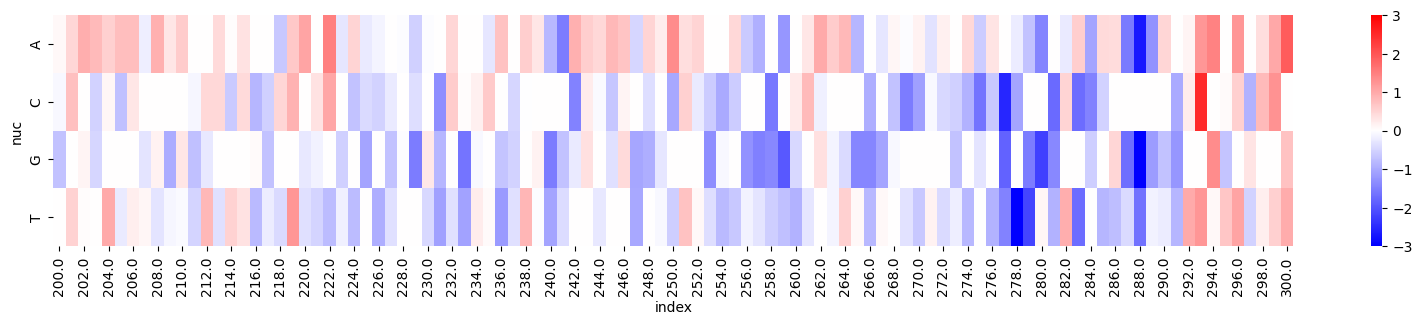

In [37]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import pandas as pd

df = pd.read_csv('variant_Switched_Bm_IGHDnegx_mean.csv')
new_data = []

for idx, row in df.iterrows():
    position = row['snp_relative_pos']
    new_data.append([position, 'A', row['mean_base_A_pred_peak']])
    new_data.append([position, 'T', row['mean_base_T_pred_peak']])
    new_data.append([position, 'C', row['mean_base_C_pred_peak']])
    new_data.append([position, 'G', row['mean_base_G_pred_peak']])

new_df = pd.DataFrame(new_data, columns=['index', 'nuc', 'pred_peak_value'])
data = new_df[(new_df['index'] >= 200.0) & (new_df['index'] <= 300.0)]

heatmap_data = data.pivot(index ='nuc', columns ='index', values='pred_peak_value')
plt.figure(figsize=(20, 3))
cmap = LinearSegmentedColormap.from_list('custom_cmap', ['blue', 'white', 'red'])
sns.heatmap(heatmap_data, cmap=cmap, center=0, vmin=-3, vmax=3)
plt.savefig("heatmap_Switched_Bm_IGHDnegchr22_39351775-100bpmean.pdf", dpi=400, bbox_inches='tight')

# Line chart

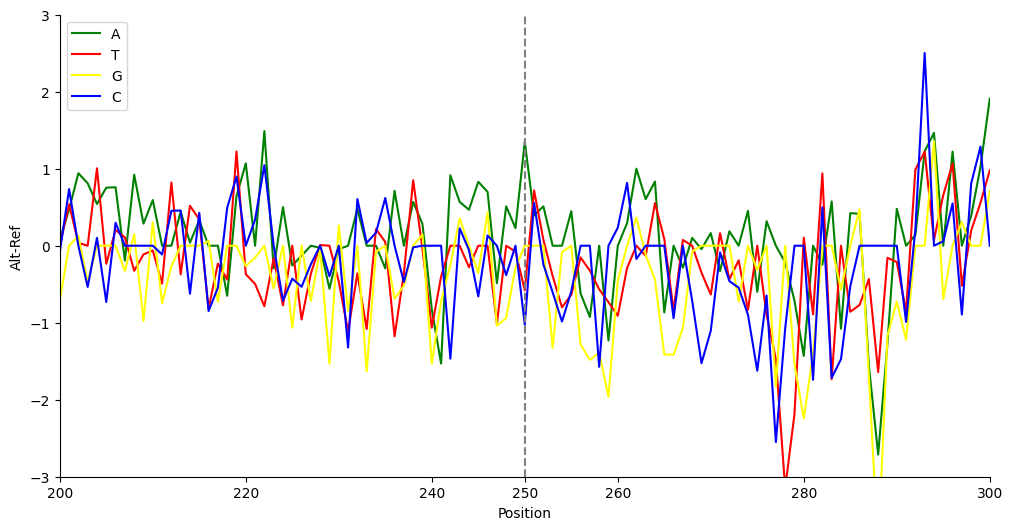

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('variant_Switched_Bm_IGHDnegx_mean.csv')
df_subset = df[(df['snp_relative_pos'] >= 200) & (df['snp_relative_pos'] <= 300)]

start_position = df_subset['snp_relative_pos'].min()
end_position = df_subset['snp_relative_pos'].max()
mid_position = (start_position + end_position) // 2

plt.figure(figsize=(12, 6))

plt.plot(df_subset['snp_relative_pos'], df_subset['mean_base_A_pred_peak'], color='green', label='A')
plt.plot(df_subset['snp_relative_pos'], df_subset['mean_base_T_pred_peak'], color='red', label='T')
plt.plot(df_subset['snp_relative_pos'], df_subset['mean_base_G_pred_peak'], color='yellow', label='G')
plt.plot(df_subset['snp_relative_pos'], df_subset['mean_base_C_pred_peak'], color='blue', label='C')

plt.ylim(-3, 3)

plt.xlabel('Position')
plt.ylabel('Alt-Ref')
plt.legend()
current_xticks = plt.xticks()[0]
current_xticklabels = [str(int(label)) for label in current_xticks]

new_xticks = sorted(set(current_xticks).union([start_position, mid_position, end_position]))
new_xticklabels = [str(int(label)) for label in new_xticks]

plt.xticks(new_xticks, new_xticklabels)
plt.axvline(x=mid_position, color='gray', linestyle='--')
plt.xlim(start_position, end_position)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)

plt.savefig('Line_Switched_Bm_IGHDnegchr22_39351775-100bpmean.pdf', dpi=400, bbox_inches='tight')


# Sequence Logo

/tmp/ipykernel_200943/3503648627.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_subset.rename(columns={


<Figure size 900x600 with 0 Axes>

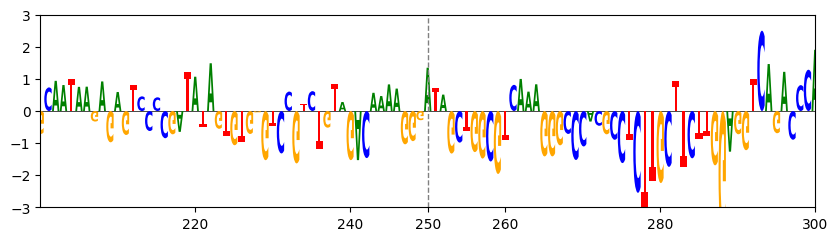

In [18]:
import pandas as pd
import logomaker as lm
import matplotlib.pyplot as plt

df_data = pd.read_csv('variant_Switched_Bm_IGHDnegx_mean.csv')

def keep_max_abs(row):
    
    abs_values = row[1:].abs()
    max_index = abs_values.idxmax()
    new_row = row.copy()
    new_row.loc[new_row.index != max_index] = 0
    return new_row

df = df_data.apply(keep_max_abs, axis=1)
df['position'] = df_data['snp_relative_pos']
df_subset = df[(df['position'] >= 200) & (df['position'] <= 300)]
df_subset.set_index('position', inplace=True)
df_subset.rename(columns={
    "mean_base_A_pred_peak": "A",
    "mean_base_T_pred_peak": "T",
    "mean_base_C_pred_peak": "C",
    "mean_base_G_pred_peak": "G"
}, inplace=True)
df_subset = df_subset[['A', 'C', 'G', 'T']]

start_position = df_subset.index.min()
end_position = df_subset.index.max()
mid_position = (start_position + end_position) // 2

plt.figure(figsize=(9, 6))
logo = lm.Logo(df_subset, color_scheme='classic')
current_xticks = plt.xticks()[0]

new_xticks = sorted(set(current_xticks).union([start_position, mid_position, end_position])-{200})
new_xticklabels = [str(int(tick)) for tick in new_xticks]

plt.xticks(new_xticks, new_xticklabels)
plt.axvline(x=mid_position, color='gray', linestyle='--',linewidth=1)
plt.xlim(start_position, end_position)
plt.ylim(-3, 3)


plt.savefig('ATCG_Switched_Bm_IGHDnegchr22_39351775-100bpmean.pdf', dpi=400, bbox_inches='tight')